# `mm` — fast, multimodal context for agents

A walkthrough of [`mm`](https://vlm-run.github.io/mm/intro) — fast, multimodal context for agents focused on getting text-based context out of images, videos, and audio so you can pipe them into any LLM workflow.

This notebook covers:

1. Setting up a local VLM (**Gemma 4** via Ollama) and confirming it works end-to-end
2. Installing `mm` and pointing it at the local VLM
3. The core commands: `mm find`, `mm wc`, `mm cat`, `mm grep`
4. A few ways to compose Gemma 4 with `mm`-style prompting for your own pipelines

**What to have ready:** upload one image and one video for this walkthrough (drop them into the Colab file browser on the left). The examples here use a photo of blueberries and a short fitness clip, but any image + video will work — swap in your own and the commands all still run.

> Make sure the runtime is set to **GPU (T4)** — Runtime → Change runtime type.

## 0. GPU check

`mm cat -m accurate` sends images to a local VLM. On CPU that round-trip takes minutes per image instead of seconds, so verify the runtime has a GPU before going further.

If no GPU is detected: **Runtime → Change runtime type → T4 GPU**, then re-run from the top.

In [1]:
import subprocess

gpu = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
if gpu.returncode == 0:
    print("✅ GPU detected — Ollama will use it automatically.\n")
    print(gpu.stdout)
else:
    print("⚠️  No GPU detected. You're on CPU — accurate-mode VLM calls will be SLOW.")
    print("   Fix: Runtime → Change runtime type → T4 GPU, then re-run this notebook.")

✅ GPU detected — Ollama will use it automatically.

Thu Apr 23 23:39:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/

## 1. Point at your files and pick a model

Set the paths to the image and video you just uploaded, and pick a Gemma 4 tag to self-host.

**Gemma 4** (released April 2, 2026) is Google DeepMind's latest open multimodal family, built from the same research as Gemini 3, with native text + image input and variable aspect ratio / resolution support.

| Tag | Size on disk | Context | Fits on T4 (15 GB)? |
|---|---|---|---|
| `gemma4:e2b` | 7.2 GB | 128K | ✅ yes (lightest) |
| `gemma4:e4b` (alias `gemma4:latest`) | 9.6 GB | 128K | ✅ yes (**default**) |
| `gemma4:26b` (MoE, 4B active) | 18 GB | 256K | ❌ no |
| `gemma4:31b` (dense) | 20 GB | 256K | ❌ no |

On a Colab T4, **`gemma4:e4b`** is the sweet spot — best quality that still fits. Drop to `gemma4:e2b` if you hit OOM.

In [2]:
# The exact tag string Ollama uses (must match the NAME column from `ollama list`).
MODEL = "gemma4:e4b"
# MODEL = "gemma4:e2b"  # lighter fallback

# Point these at the files you uploaded to the Colab file browser (left sidebar).
# Note: change filenames to your specific filenames if needed.
ORIGINAL_IMAGE_PATH = "/content/blueberry_1.jpg"
ORIGINAL_VIDEO_PATH = "/content/IMG_1632_cropped.mov"

## 2. Downsample the image and video

Gemma 4 handles variable aspect ratios and resolutions natively, so we don't need to snap to a specific patch size. We *do* still cap the long edge for speed: bigger inputs mean more vision tokens, more VRAM, and longer generation.

- **Image**: 768px long edge is a reasonable default for E4B.
- **Video**: `mm` builds an 8-frame mosaic, so total pixels add up fast — we go smaller (320px long edge) to keep the mosaic manageable.

In [3]:
# ─── Downsample the image ────────────────────────────────────────────────────
import os
from PIL import Image

IMAGE_TARGET_LONG_EDGE = 768  # raise to 1024 for more detail, drop to 512 for speed

img = Image.open(ORIGINAL_IMAGE_PATH)

if img.width >= img.height:
    new_w = IMAGE_TARGET_LONG_EDGE
    new_h = round(IMAGE_TARGET_LONG_EDGE * img.height / img.width)
else:
    new_h = IMAGE_TARGET_LONG_EDGE
    new_w = round(IMAGE_TARGET_LONG_EDGE * img.width / img.height)

img_resized = img.resize((new_w, new_h), Image.LANCZOS)

IMAGE_PATH = ORIGINAL_IMAGE_PATH.replace(".jpg", "_sm.jpg")
img_resized.save(IMAGE_PATH, quality=90)

print(
    f"Original:    {img.width}x{img.height} ({os.path.getsize(ORIGINAL_IMAGE_PATH) / 1e6:.1f} MB)"
)
print(
    f"Downsampled: {img_resized.width}x{img_resized.height} ({os.path.getsize(IMAGE_PATH) / 1e6:.1f} MB)"
)
print(f"Saved to:    {IMAGE_PATH}")

Original:    4608x3456 (6.7 MB)
Downsampled: 768x576 (0.2 MB)
Saved to:    /content/blueberry_1_sm.jpg


In [ ]:
# ─── Downsample the video ────────────────────────────────────────────────────
# iPhone videos store frames in landscape (e.g. 3840x2160) with a rotation
# metadata flag, so we read that tag to know the *displayed* orientation.
import subprocess
import sys
import time

VIDEO_TARGET_LONG_EDGE = 320

base, ext = os.path.splitext(ORIGINAL_VIDEO_PATH)
VIDEO_PATH = f"{base}_sm.mp4"  # always output as .mp4 for compatibility

if os.path.exists(VIDEO_PATH):
    probe_sm = subprocess.run(
        [
            "ffprobe",
            "-v",
            "error",
            "-select_streams",
            "v:0",
            "-show_entries",
            "stream=width,height",
            "-of",
            "csv=p=0",
            VIDEO_PATH,
        ],
        capture_output=True,
        text=True,
    )
    w, h = [int(x) for x in probe_sm.stdout.strip().split(",")[:2]]
    size = os.path.getsize(VIDEO_PATH) / 1e6
    print(f"✅ Already exists: {VIDEO_PATH} ({w}x{h}, {size:.1f} MB)")

else:
    # Probe dimensions, duration, AND rotation metadata
    probe = subprocess.run(
        [
            "ffprobe",
            "-v",
            "error",
            "-select_streams",
            "v:0",
            "-show_entries",
            "stream=width,height,duration:stream_side_data=rotation",
            "-of",
            "default=noprint_wrappers=1:nokey=0",
            ORIGINAL_VIDEO_PATH,
        ],
        capture_output=True,
        text=True,
    )

    orig_w = orig_h = 0
    total_dur = 0
    rotation = 0
    for line in probe.stdout.splitlines():
        if line.startswith("width="):
            orig_w = int(line.split("=")[1])
        elif line.startswith("height="):
            orig_h = int(line.split("=")[1])
        elif line.startswith("duration="):
            try:
                total_dur = float(line.split("=")[1])
            except:  # noqa: E722
                pass
        elif line.startswith("rotation="):
            try:
                rotation = abs(int(line.split("=")[1]))
            except:  # noqa: E722
                pass

    display_w, display_h = (orig_h, orig_w) if rotation in (90, 270) else (orig_w, orig_h)

    if display_w >= display_h:
        scale_filter = f"scale={VIDEO_TARGET_LONG_EDGE}:-2"
    else:
        scale_filter = f"scale=-2:{VIDEO_TARGET_LONG_EDGE}"

    print(
        f"Original:  {orig_w}x{orig_h} (rotation={rotation}°, displays as {display_w}x{display_h})"
    )
    print(f"           ({os.path.getsize(ORIGINAL_VIDEO_PATH) / 1e6:.1f} MB, {total_dur:.1f}s)")
    print(f"Exporting: long edge → {VIDEO_TARGET_LONG_EDGE}px → {VIDEO_PATH}")
    print()

    t0 = time.time()
    proc = subprocess.Popen(
        [
            "ffmpeg",
            "-y",
            "-i",
            ORIGINAL_VIDEO_PATH,
            "-vf",
            scale_filter,
            "-c:v",
            "libx264",
            "-preset",
            "fast",
            "-crf",
            "23",
            "-pix_fmt",
            "yuv420p",
            "-c:a",
            "aac",
            "-b:a",
            "128k",
            "-progress",
            "pipe:1",
            "-nostats",
            VIDEO_PATH,
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )

    for line in proc.stdout:
        line = line.strip()
        if line.startswith("out_time_ms="):
            us = int(line.split("=")[1])
            secs = us / 1_000_000
            if total_dur > 0:
                pct = min(secs / total_dur * 100, 100)
                sys.stdout.write(f"\r  ⏳ {pct:5.1f}%  ({secs:.1f}s / {total_dur:.1f}s)")
            else:
                sys.stdout.write(f"\r  ⏳ {secs:.1f}s encoded")
            sys.stdout.flush()

    proc.wait()
    elapsed = time.time() - t0

    if proc.returncode != 0:
        print(f"\n❌ ffmpeg failed:\n{proc.stderr.read()}")
    else:
        probe_sm = subprocess.run(
            [
                "ffprobe",
                "-v",
                "error",
                "-select_streams",
                "v:0",
                "-show_entries",
                "stream=width,height",
                "-of",
                "csv=p=0",
                VIDEO_PATH,
            ],
            capture_output=True,
            text=True,
        )
        new_w, new_h = [int(x) for x in probe_sm.stdout.strip().split(",")[:2]]
        new_size = os.path.getsize(VIDEO_PATH) / 1e6

        print(f"\r  ✅ Done in {elapsed:.1f}s")
        print(f"\nDownsampled: {new_w}x{new_h} ({new_size:.1f} MB)")
        print(f"Saved to:    {VIDEO_PATH}")

✅ Already exists: /content/IMG_1632_cropped_sm.mp4 (320x568, 0.2 MB)


## 3. Preview the image and video

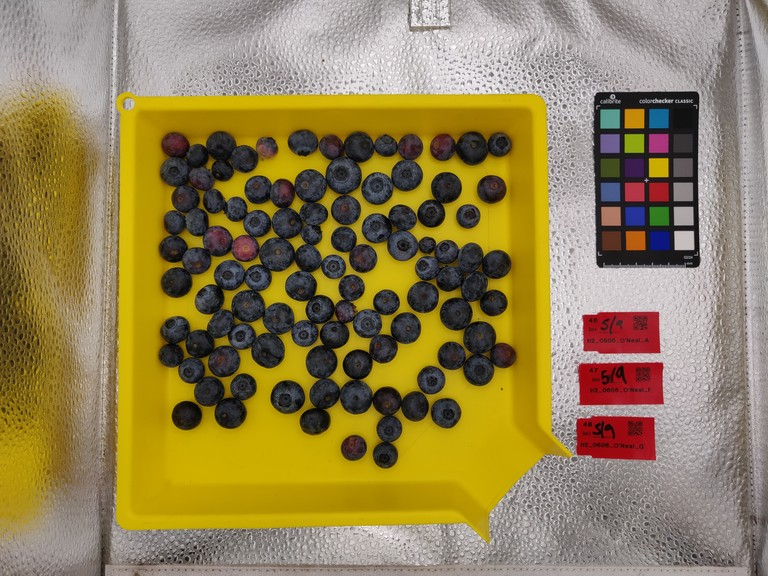

In [5]:
from IPython.display import Image, display

display(Image(IMAGE_PATH))

In [6]:
from IPython.display import Video, display

display(Video(VIDEO_PATH, embed=True))

## 4. Spin up Ollama and pull Gemma 4

`mm`'s accurate-mode operations need a VLM on a live server. We'll self-host Gemma 4 with Ollama.

- **Ollama v0.20.0+** is required for Gemma 4 (landed April 3, 2026)
- `zstd` is needed to extract Ollama's tarball; `pciutils` silences the GPU-detection warning from the installer
- Colab has no systemd, so we start `ollama serve` with `nohup` so it keeps running across cells

In [7]:
# ─── Install Ollama + start server (idempotent; safe to re-run) ─────────────
!dpkg -s zstd pciutils >/dev/null 2>&1 || apt-get install -y zstd pciutils
!which ollama >/dev/null 2>&1 || curl -fsSL https://ollama.com/install.sh | sh
!pgrep -x ollama >/dev/null 2>&1 || (nohup ollama serve > /tmp/ollama.log 2>&1 &)
!sleep 3
!ollama --version

ollama version is 0.21.1


In [8]:
# Pull Gemma 4 (~9.6 GB the first time; cached afterwards)
!ollama pull {MODEL}
!ollama list  # confirm the NAME column matches MODEL exactly


NAME          ID              SIZE      MODIFIED               
gemma4:e4b    c6eb396dbd59    9.6 GB    Less than a second ago    


## 5. Sanity check: Gemma 4 out of the box

Before plugging `mm` in, let's confirm Gemma 4 actually works on our image — just a plain VLM call against the Ollama server, image in, caption out. This is the simplest possible sanity check: if this works, `mm`'s accurate mode will work too, because `mm` talks to the same endpoint.


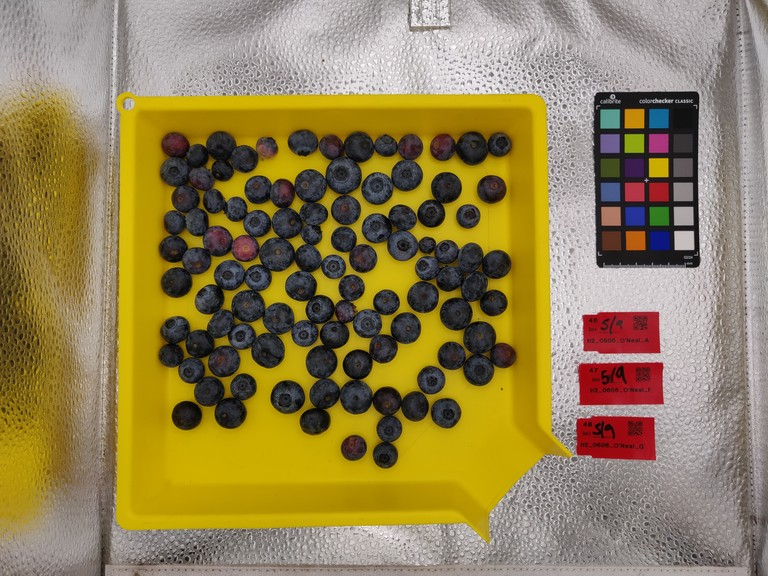

In [9]:
# ─── Gemma 4 VQA → image + caption ──────────────────────────────────────────
# Ask Gemma an open-ended question about the image. Render the image on the
# left and the answer as a caption on the right.
import base64
import io
import requests
from IPython.display import HTML, display as ipy_display

OLLAMA_URL = "http://localhost:11434"

QUESTION = (
    "Describe this image in 2-4 sentences. What's the setup, what's in it, "
    "and what does it look like it was made for?"
)

buf = io.BytesIO()
img_resized.convert("RGB").save(buf, format="JPEG", quality=90)
img_b64 = base64.b64encode(buf.getvalue()).decode()

resp = requests.post(
    f"{OLLAMA_URL}/api/generate",
    json={
        "model": MODEL,
        "prompt": QUESTION,
        "images": [img_b64],
        "stream": False,
        "options": {"temperature": 0.2, "num_predict": 512},
    },
    timeout=180,
).json()
answer = resp["response"].strip()

# ─── Render: image left, caption right ──────────────────────────────────────
img_src = f"data:image/jpeg;base64,{img_b64}"

html = f"""
<div style='display:flex; flex-wrap:wrap; gap:16px; align-items:flex-start'>
  <div style='flex:2 1 520px; min-width:360px; text-align:center'>
    <img src='{img_src}' style='max-width:100%; border-radius:6px'>
    <div style='font-size:12px; color:#666; margin-top:6px'>Input image</div>
  </div>
  <div style='flex:1 1 320px; min-width:280px; max-width:480px;
              background:#f7f7f9; border-radius:8px; padding:14px 18px;
              font-family:-apple-system,BlinkMacSystemFont,sans-serif; font-size:14px;
              line-height:1.5; color:#2e3138'>
    <div style='font-size:11px; letter-spacing:0.06em; text-transform:uppercase;
                color:#888; margin-bottom:6px'>Question</div>
    <div style='margin-bottom:12px; font-style:italic'>{QUESTION}</div>
    <div style='font-size:11px; letter-spacing:0.06em; text-transform:uppercase;
                color:#888; margin-bottom:6px'>Gemma 4 ({MODEL})</div>
    <div>{answer}</div>
  </div>
</div>
"""
ipy_display(HTML(html))

## 6. Install `mm`

The official installer drops the binary in `~/.local/bin`.

In [10]:
!pip install mm-ctx

In [11]:
# Verify install and version
!which mm && mm --version

/usr/local/bin/mm
mm v0.7.3


## 7. Point `mm` at the local Ollama server

`mm` ships with three reserved profiles: `ollama`, `gemini`, and `vlmrun`. We update the `ollama` profile to point at our local server and the Gemma 4 model we just pulled, then activate it.

In [12]:
!mm profile update ollama --base-url http://localhost:11434/v1 --model {MODEL}
!mm profile use ollama
!mm profile list  # active profile is marked with ●

Updated profile: ollama (base_url=http://localhost:11434/v1, model=gemma4:e4b)  
(/root/.config/mm/mm.toml)
Switched to profile: ollama  (/root/.config/mm/mm.toml)
                                   Profiles                                   
╭────┬─────────┬──────────────────────────────┬──────────────────────────────╮
│    │ profile │ base_url                     │ model                        │
├────┼─────────┼──────────────────────────────┼──────────────────────────────┤
│    │ gemini  │ https://openrouter.ai/api/v1 │ google/gemini-2.5-flash-lite │
│ ●  │ ollama  │ http://localhost:11434/v1    │ gemma4:e4b                   │
│    │ vlmrun  │ https://mm-ctx.ngrok.io/v1   │ Qwen/Qwen3.5-0.8B            │
╰────┴─────────┴──────────────────────────────┴──────────────────────────────╯


## 8. `mm find` and `mm wc` — metadata, no VLM

These commands work purely on file metadata — no model call, no GPU use.

- **`mm find`** — tabular listing: kind, size, extension, dimensions
- **`mm wc`** — quick summary: file count, bytes, estimated lines/tokens

In [25]:
!mm cat {ORIGINAL_IMAGE_PATH} -m accurate --verbose --no-cache

A brightly lit, overhead photograph captures a vibrant still life arrangement 
centered around a yellow, rectangular serving tray. The tray is densely filled 
with a generous scattering of dark blue to purple berries, which appear to be 
blueberries. The berries are clustered naturally, creating a rich, deep color 
contrast against the bright, uniform yellow of the tray itself.

The tray rests on a textured, metallic surface, likely brushed aluminum or 
stainless steel, which provides a cool, neutral background. To the right side of
the tray, several technical color reference tools are placed. These include a 
large, grid-patterned color checker chart, displaying dozens of standardized 
colored squares, and three smaller, labeled color swatch cards. These 
accessories suggest that the photograph is either part of a professional product
shoot, a scientific study, or a color grading process, emphasizing accurate 
color representation. The overall composition is clean and highly detailed,

In [31]:
!mm cat {ORIGINAL_IMAGE_PATH} -m accurate -p resize --verbose --no-cache

pipeline
  └─ encode: resize • 680ms → 1 parts (1 image)
2.0s • 6.4 MB • 3.2 MB/s


In [34]:
!mm cat --help

                                                                                
 Usage: mm cat [OPTIONS] [FILES]...                                             
                                                                                
 Extract and describe file content.                                             
                                                                                
                                                                                
 Behavior auto-detects from file type. Default mode is 'fast' (local            
 extraction). Use '-m accurate' for LLM-powered descriptions.                   
                                                                                
                                                                                
 Images:   fast = metadata.  accurate = VLM caption.                            
 Videos:   fast = metadata.  accurate = mosaic → VLM description.               
 Audio:    fast = metadata. 

In [33]:
!mm cat {ORIGINAL_IMAGE_PATH} --encode.strategy resize max-width 800 -m accurate --verbose --no-cache

<blueberry_1.jpg>
A bright, vibrant yellow, rectangular tray serves as the central focus of this 
image, resting on a highly reflective, textured metallic surface. The tray is 
densely filled with a generous quantity of fresh blueberries. The blueberries 
are scattered across the yellow surface, creating a rich, deep blue contrast 
against the bright background. They appear plump and ripe, suggesting a recent 
harvest or careful arrangement for display.

The setup suggests a professional context, likely related to food photography, 
color science, or product testing. To the right of the yellow tray, several 
color calibration tools are visible. The most prominent is a standard color 
checker chart, featuring a grid of uniformly colored squares used to ensure 
accurate color representation in photography. Below this chart are three 
smaller, square calibration cards, each labeled with specific codes (e.g., 
"H2_0608_O'Neal_A"). These tools, along with the reflective background, indicate

In [29]:
!mm cat --list-pipelines


╭─ Pipelines ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│                                                                                                                                                                                           │
│  Kind      Mode      Encoder                                                                                                                                                              │
│  image     fast      resize(strategy_opts={'max_width': 512})                                                                                                                             │
│                      /usr/local/lib/python3.12/dist-packages/mm/pipelines/image/fast.yaml                                                                                                 │
│  image     accurate  resize(strategy_opts={'max

In [ ]:
# Tabular listing: kind, size, ext, dimensions, etc.
!mm find {IMAGE_PATH}

In [ ]:
# Quick summary: file count, bytes, estimated lines/tokens
!mm wc {IMAGE_PATH}

## 9. `mm cat` on an image

`mm cat` extracts text context from a file. It has two modes:

- **`-m fast`** — heuristic-only, no VLM call (quick metadata summary)
- **`-m accurate`** — sends the file to the configured VLM for rich description

Fast mode returns in milliseconds; accurate mode takes a few seconds per image on a T4.

In [ ]:
# Fast mode: no VLM call, just metadata
!mm cat {IMAGE_PATH} -m fast --verbose --no-cache

In [ ]:
# Accurate mode: sends the image to Gemma 4 via Ollama
!mm cat {IMAGE_PATH} -m accurate --verbose --no-cache

## 10. `mm cat` on a video

For videos, `mm` samples frames, builds a mosaic, and feeds it to the VLM. Same two modes as images.

In [ ]:
# Fast mode: no VLM call
!mm cat {VIDEO_PATH} -m fast --verbose --no-cache

In [ ]:
# Accurate mode: mosaic → Gemma 4
!mm cat {VIDEO_PATH} -m accurate --verbose --no-cache

## 11. `mm grep` — semantic search across a folder

`mm grep` runs a natural-language query against every file in a directory, using the active VLM profile. This is the piece that's hardest to replicate with plain `grep` or `find`: matching *meaning* rather than substrings.

In [ ]:
!mm grep "blueberries" /content -s --index

In [ ]:
!ls /content

In [ ]:
!mm grep --help

# More examples


In [ ]:
!curl -sL -o /content/bench.jpg https://storage.googleapis.com/vlm-data-public-prod/hub/examples/image.caption/bench.jpg
!curl -sL -o /content/Timelapse.mp4 https://storage.googleapis.com/vlm-data-public-prod/hub/examples/video/Timelapse.mp4
!ls -lh /content/bench.jpg /content/Timelapse.mp4

In [ ]:
from IPython.display import Image, display

display(Image("/content/bench.jpg"))

In [ ]:
from IPython.display import Video, display

display(Video("/content/Timelapse.mp4", embed=True))

In [ ]:
!mm cat /content/bench.jpg -m fast --no-cache

In [ ]:
!mm cat /content/bench.jpg -m accurate --no-cache

In [ ]:
!mm cat /content/Timelapse.mp4 -m fast --no-cache

In [ ]:
!mm cat /content/Timelapse.mp4 -m accurate --no-cache

In [ ]:
# Run 1 (probably the 24s you saw) — includes cold model load
!time mm cat /content/bench.jpg -m accurate --no-cache

# Run 2 — model is warm, pure inference
!time mm cat /content/bench.jpg -m accurate --no-cache

# Check if the model is currently loaded and how much VRAM it's using
!curl -s http://localhost:11434/api/ps | python -m json.tool

In [ ]:
# ─── Benchmarking helper (with input dimensions) ────────────────────────────
import subprocess
import time
import os
from PIL import Image


def probe_dims(path):
    """Return (width, height, duration_s) for images/videos. Duration is None for images."""
    ext = os.path.splitext(path)[1].lower()
    if ext in (".jpg", ".jpeg", ".png", ".webp"):
        with Image.open(path) as im:
            return im.width, im.height, None
    else:
        probe = subprocess.run(
            [
                "ffprobe",
                "-v",
                "error",
                "-select_streams",
                "v:0",
                "-show_entries",
                "stream=width,height,duration",
                "-of",
                "default=noprint_wrappers=1:nokey=1",
                path,
            ],
            capture_output=True,
            text=True,
        )
        lines = probe.stdout.strip().splitlines()
        w, h = int(lines[0]), int(lines[1])
        dur = float(lines[2]) if len(lines) > 2 else None
        return w, h, dur


def benchmark_mm(path, label=None, model="gemma4:e4b"):
    label = label or os.path.basename(path)
    w, h, dur = probe_dims(path)
    size_mb = os.path.getsize(path) / 1e6
    rows = []

    for mode in ("fast", "accurate"):
        t0 = time.time()
        proc = subprocess.run(
            ["mm", "cat", path, "-m", mode, "--no-cache"],
            capture_output=True,
            text=True,
        )
        wall = time.time() - t0
        output = proc.stdout.strip()
        n_chars = len(output)
        est_tokens = n_chars / 4
        tok_per_s = est_tokens / wall if wall > 0 and mode == "accurate" else None

        rows.append(
            {
                "input": label,
                "dims": f"{w}x{h}",
                "duration_s": round(dur, 1) if dur is not None else None,
                "pixels_M": round(w * h / 1e6, 2),
                "size_MB": round(size_mb, 2),
                "mode": mode,
                "wall_s": round(wall, 2),
                "est_tokens": round(est_tokens),
                "tok_per_s": round(tok_per_s, 1) if tok_per_s else None,
            }
        )
        print(
            f"  {mode:9s} → {wall:5.1f}s  ({n_chars} chars out"
            + (f", ~{tok_per_s:.1f} tok/s)" if tok_per_s else ")")
        )

    return rows

In [ ]:
# ─── Run the benchmark ──────────────────────────────────────────────────────
# IMAGE_PATH and VIDEO_PATH are your blueberry + fitness from earlier cells.
# bench.jpg and Timelapse.mp4 are the sample files from /content.
inputs = [
    (IMAGE_PATH, "blueberry (image)"),
    (VIDEO_PATH, "fitness (video)"),
    ("/content/bench.jpg", "bench (image)"),
    ("/content/Timelapse.mp4", "timelapse (video)"),
]

all_rows = []
for path, label in inputs:
    print(f"\n📊 {label}  ({path})")
    all_rows.extend(benchmark_mm(path, label))

In [ ]:
# ─── Summary table ──────────────────────────────────────────────────────────
import pandas as pd

df = pd.DataFrame(all_rows)

# Input-level metadata (same across fast/accurate rows, so just take first)
meta = df.groupby("input", sort=False)[["dims", "duration_s", "pixels_M", "size_MB"]].first()

# Per-mode metrics, pivoted so each input is a row
perf = df.pivot(index="input", columns="mode", values=["wall_s", "est_tokens", "tok_per_s"])
perf.columns = [f"{metric}_{mode}" for metric, mode in perf.columns]

summary = meta.join(perf)
summary = summary.reindex([label for _, label in inputs])  # preserve input order
print(summary.to_string())

In [ ]:
# ─── Accurate-mode throughput only ──────────────────────────────────────────
acc = df[df["mode"] == "accurate"][
    ["input", "dims", "duration_s", "pixels_M", "size_MB", "wall_s", "est_tokens", "tok_per_s"]
]
print(acc.to_string(index=False))
print(f"\nMedian accurate-mode throughput: {acc['tok_per_s'].median():.1f} tok/s")
print(f"Mean accurate-mode throughput:   {acc['tok_per_s'].mean():.1f} tok/s")